# Livro para consulta:
- https://jakevdp.github.io/PythonDataScienceHandbook/03.08-aggregation-and-grouping.html
- https://jakevdp.github.io/PythonDataScienceHandbook/03.09-pivot-tables.html
    

# 1. Importando bibliotecas <a name="import"></a>

<div style="text-align: right"
     
[Voltar ao índice](#Contents)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# 2. Carregando o dataframe SINASC <a name="read"></a>
<div style="text-align: right"
     
[Voltar ao índice](#Contents)

In [2]:
sinasc_raw = pd.read_csv('Profissão Cientista de Dados M9 A1 - SINASC_RO_2019.csv')
sinasc_raw.head()

,ORIGEM,CODESTAB,CODMUNNASC,LOCNASC,IDADEMAE,ESTCIVMAE,ESCMAE,CODOCUPMAE,QTDFILVIVO,QTDFILMORT,...,KOTELCHUCK,CONTADOR,munResStatus,munResTipo,munResNome,munResUf,munResLat,munResLon,munResAlt,munResArea
0,1,2679477.0,110001,1,19,5.0,8 a 11 anos,NaN,0.0,0.0,...,5,1,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
1,1,2679477.0,110001,1,29,2.0,8 a 11 anos,999992.0,1.0,0.0,...,5,2,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
2,1,2679477.0,110001,1,37,9.0,8 a 11 anos,513205.0,2.0,0.0,...,5,3,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
3,1,2516500.0,110001,1,30,5.0,12 anos ou mais,231205.0,0.0,0.0,...,4,4,ATIVO,MUNIC,Alto Alegre dos Parecis,Rondônia,-12.13178,-61.85308,397.0,3958.273
4,1,2516500.0,110001,1,30,2.0,8 a 11 anos,999992.0,1.0,0.0,...,5,5,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025


# Tarefa 2

### 1. Crie 2 faixas de Latitude do município (munResLat) sendo uma acima e outra abaixo de -10.5 e aplique o groupby usando essas faixas como chave e realize operações de soma, media, minimo, maximo, mediana, desvio padrao, variancia pra pelo menos 2 variáveis numéricas ainda não utilizadas

In [4]:
bins = [sinasc_raw['munResLat'].min(), -10.5, sinasc_raw['munResLat'].max()]
labels = ['Abaixo de -10.5', 'Acima de -10.5']

sinasc_raw['faixa_latitude'] = pd.cut(sinasc_raw['munResLat'], bins=bins, labels=labels)

analise_geo = sinasc_raw.groupby('faixa_latitude', observed=False).agg({
    'APGAR5': ['sum', 'mean', 'min', 'max', 'median', 'std', 'var'],
    'PESO': ['sum', 'mean', 'min', 'max', 'median', 'std', 'var']
})

analise_geo

APGAR5                                                  \
                      sum      mean  min   max median       std       var   
faixa_latitude                                                              
Abaixo de -10.5  117663.0  9.138874  0.0  10.0    9.0  0.806977  0.651211   
Acima de -10.5   128746.0  9.216551  0.0  10.0    9.0  0.774741  0.600224   

                     PESO                                              \
                      sum         mean  min   max  median         std   
faixa_latitude                                                          
Abaixo de -10.5  41831706  3239.503291  258  5985  3270.0  532.148867   
Acima de -10.5   45555148  3246.055864  295  5190  3275.0  556.487709   

                                
                           var  
faixa_latitude                  
Abaixo de -10.5  283182.416830  
Acima de -10.5   309678.570242

### 2. Crie 2 faixas da área dos municípios (munResArea) sendo uma acima e outra abaixo de 3000 e aplique o groupby usando essas faixas como chave e realize operações de soma, media, minimo, maximo, mediana, desvio padrao, variancia pra pelo menos 2 variáveis numéricas ainda não utilizadas


In [5]:
bins_area = [sinasc_raw['munResArea'].min(), 3000, sinasc_raw['munResArea'].max()]
labels_area = ['Abaixo de 3000 km²', 'Acima de 3000 km²']

sinasc_raw['faixa_area'] = pd.cut(sinasc_raw['munResArea'], bins=bins_area, labels=labels_area)

analise_area = sinasc_raw.groupby('faixa_area', observed=False).agg({
    'CONSULTAS': ['sum', 'mean', 'min', 'max', 'median', 'std', 'var'],
    'QTDPARTNOR': ['sum', 'mean', 'min', 'max', 'median', 'std', 'var']
})

analise_area

CONSULTAS                                               \
                         sum      mean min max median       std       var   
faixa_area                                                                  
Abaixo de 3000 km²     19272  3.738506   1   9    4.0  0.608679  0.370490   
Acima de 3000 km²      77142  3.537326   1   9    4.0  0.820967  0.673986   

                   QTDPARTNOR                                                  
                          sum      mean  min   max median       std       var  
faixa_area                                                                     
Abaixo de 3000 km²     1898.0  0.373255  0.0  10.0    0.0  0.856498  0.733588  
Acima de 3000 km²     12659.0  0.632982  0.0  41.0    0.0  1.278932  1.635668

### 3. Determine faixas na variável munResAlt e aplique o groupby usando essas faixas como chave e realize operações de soma, media, minimo, maximo, mediana, desvio padrao, variancia pra pelo menos 2 variáveis numéricas ainda não utilizadas

In [6]:
bins_area = [sinasc_raw['munResArea'].min(), 3000, sinasc_raw['munResArea'].max()]
labels_area = ['Abaixo de 3000 km²', 'Acima de 3000 km²']

sinasc_raw['faixa_area'] = pd.cut(sinasc_raw['munResArea'], bins=bins_area, labels=labels_area)

analise_area = sinasc_raw.groupby('faixa_area', observed=False).agg({
    'CONSULTAS': ['sum', 'mean', 'min', 'max', 'median', 'std', 'var'],
    'QTDPARTNOR': ['sum', 'mean', 'min', 'max', 'median', 'std', 'var']
})

analise_area

CONSULTAS                                               \
                         sum      mean min max median       std       var   
faixa_area                                                                  
Abaixo de 3000 km²     19272  3.738506   1   9    4.0  0.608679  0.370490   
Acima de 3000 km²      77142  3.537326   1   9    4.0  0.820967  0.673986   

                   QTDPARTNOR                                                  
                          sum      mean  min   max median       std       var  
faixa_area                                                                     
Abaixo de 3000 km²     1898.0  0.373255  0.0  10.0    0.0  0.856498  0.733588  
Acima de 3000 km²     12659.0  0.632982  0.0  41.0    0.0  1.278932  1.635668

### 4. Plote no mesmo grafico ao longo do tempo a idade media das mulheres de cada regiao imediatas de rondonia


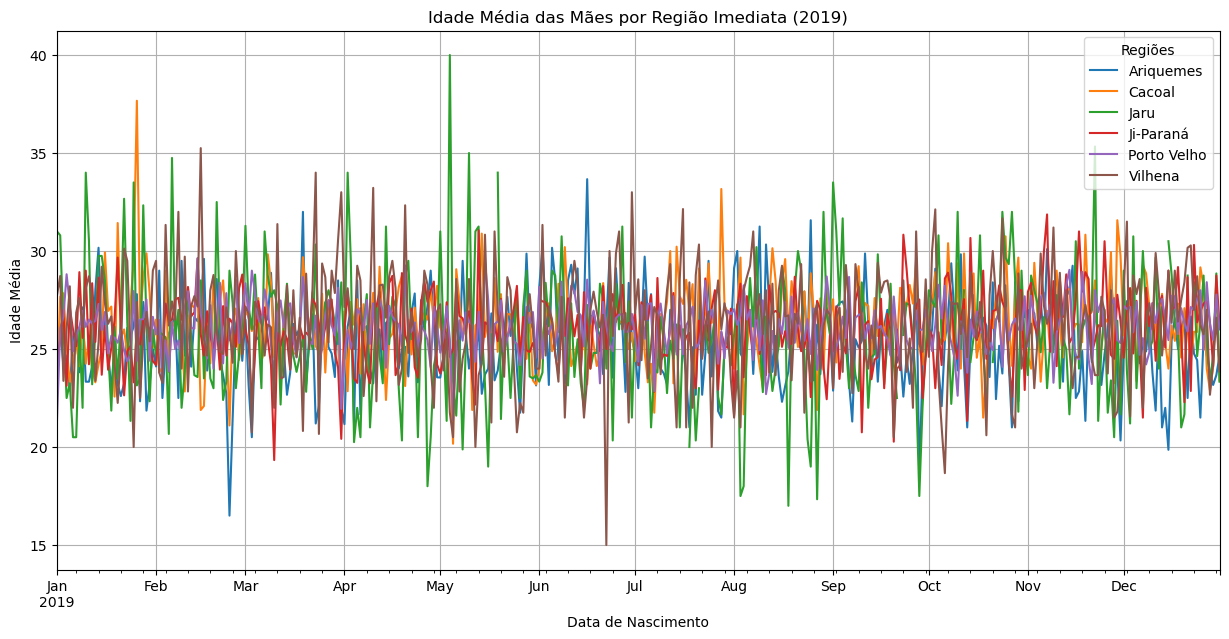

In [8]:
imediatas = {
    "Candeias do Jamari": "Porto Velho", "Guajará-Mirim": "Porto Velho", "Itapuã do Oeste": "Porto Velho",
    "Nova Mamoré": "Porto Velho", "Porto Velho": "Porto Velho", "Ariquemes": "Ariquemes",
    "Alto Paraíso": "Ariquemes", "Buritis": "Ariquemes", "Cacaulândia": "Ariquemes",
    "Campo Novo de Rondônia": "Ariquemes", "Cujubim": "Ariquemes", "Monte Negro": "Ariquemes",
    "Rio Crespo": "Ariquemes", "Jaru": "Jaru", "Governador Jorge Teixeira": "Jaru",
    "Machadinho D'Oeste": "Jaru", "Theobroma": "Jaru", "Vale do Anari": "Jaru",
    "Alvorada D'Oeste": "Ji-Paraná", "Costa Marques": "Ji-Paraná", "Ji-Paraná": "Ji-Paraná",
    "Mirante da Serra": "Ji-Paraná", "Nova União": "Ji-Paraná", "Ouro Preto do Oeste": "Ji-Paraná",
    "Presidente Médici": "Ji-Paraná", "São Francisco do Guaporé": "Ji-Paraná",
    "São Miguel do Guaporé": "Ji-Paraná", "Seringueiras": "Ji-Paraná", "Teixeirópolis": "Ji-Paraná",
    "Urupá": "Ji-Paraná", "Vale do Paraíso": "Ji-Paraná", "Cacoal": "Cacoal",
    "Alta Floresta D'Oeste": "Cacoal", "Alto Alegre dos Parecis": "Cacoal",
    "Castanheiras": "Cacoal", "Espigão D'Oeste": "Cacoal", "Ministro Andreazza": "Cacoal",
    "Nova Brasilândia D'Oeste": "Cacoal", "Novo Horizonte do Oeste": "Cacoal",
    "Parecis": "Cacoal", "Pimenta Bueno": "Cacoal", "Primavera de Rondônia": "Cacoal",
    "Rolim de Moura": "Cacoal", "Santa Luzia D'Oeste": "Cacoal", "São Felipe D'Oeste": "Cacoal",
    "Vilhena": "Vilhena", "Cabixi": "Vilhena", "Cerejeiras": "Vilhena",
    "Chupinguaia": "Vilhena", "Colorado do Oeste": "Vilhena", "Corumbiara": "Vilhena",
    "Pimenteiras do Oeste": "Vilhena"
}

sinasc_raw['regiao_imediata'] = sinasc_raw['munResNome'].map(imediatas)

sinasc_raw['DTNASC'] = pd.to_datetime(sinasc_raw['DTNASC'])

grafico_data = sinasc_raw.pivot_table(values='IDADEMAE', 
                                      index='DTNASC', 
                                      columns='regiao_imediata', 
                                      aggfunc='mean')

import matplotlib.pyplot as plt

grafico_data.plot(figsize=(15, 7))
plt.title('Idade Média das Mães por Região Imediata (2019)')
plt.ylabel('Idade Média')
plt.xlabel('Data de Nascimento')
plt.legend(title='Regiões')
plt.grid(True)
plt.show()

### 5. Utilize a tabela do link abaixo e crie faixas utilizando o mapping e gere agrupamentos utilizando essas faixas como chave


### 5.1 IDH
A - https://pt.wikipedia.org/wiki/Lista_de_munic%C3%ADpios_de_Rond%C3%B4nia_por_IDH-M


In [10]:
idh_map = {
    "Porto Velho": "IDH-M Alto", "Vilhena": "IDH-M Alto", "Cacoal": "IDH-M Alto",
    "Ji-Paraná": "IDH-M Alto", "Ariquemes": "IDH-M Alto", "Pimenta Bueno": "IDH-M Alto",
    "Rolim de Moura": "IDH-M Alto", "Jaru": "IDH-M Médio", "Guajará-Mirim": "IDH-M Médio",
    "Castanheiras": "IDH-M Médio", "Governador Jorge Teixeira": "IDH-M Baixo"
}

sinasc_raw['idh_faixa'] = sinasc_raw['munResNome'].map(idh_map)

analise_idh = sinasc_raw.groupby('idh_faixa', observed=False).agg({
    'IDADEMAE': ['mean', 'median', 'std'],
    'PESO': 'mean'
})
print(analise_idh)

              IDADEMAE                          PESO
                  mean median       std         mean
idh_faixa                                           
IDH-M Alto   26.280332   26.0  6.415374  3245.623791
IDH-M Baixo  24.401786   24.0  5.698838  3238.991071
IDH-M Médio  25.767414   25.0  6.503684  3283.434475


### 5.2 IFDM
B - https://pt.wikipedia.org/wiki/Lista_de_munic%C3%ADpios_de_Rond%C3%B4nia_por_IFDM


In [11]:
ifdm_map = {
    "Ariquemes": "Desenvolvimento Moderado", "Vilhena": "Desenvolvimento Moderado",
    "Porto Velho": "Desenvolvimento Moderado", "Ji-Paraná": "Desenvolvimento Moderado",
    "Cacoal": "Desenvolvimento Moderado", "Pimenta Bueno": "Desenvolvimento Moderado",
    "Cerejeiras": "Desenvolvimento Regular", "Guajará-Mirim": "Desenvolvimento Regular"
}

sinasc_raw['ifdm_faixa'] = sinasc_raw['munResNome'].map(ifdm_map)

# Agrupamento e análise (ex: Consultas de pré-natal e Apgar)
analise_ifdm = sinasc_raw.groupby('ifdm_faixa', observed=False).agg({
    'CONSULTAS': 'mean',
    'APGAR5': ['mean', 'min', 'max']
})
print(analise_ifdm)

                         CONSULTAS    APGAR5           
                              mean      mean  min   max
ifdm_faixa                                             
Desenvolvimento Moderado  3.518458  9.176015  0.0  10.0
Desenvolvimento Regular   3.252456  9.255489  0.0  10.0


### 5.3 PIB
C - https://pt.wikipedia.org/wiki/Lista_de_munic%C3%ADpios_de_Rond%C3%B4nia_por_PIB


In [12]:
pib_map = {
    "Porto Velho": "Acima de 1 Bilhão", "Ji-Paraná": "Acima de 1 Bilhão",
    "Vilhena": "Acima de 1 Bilhão", "Cacoal": "Acima de 1 Bilhão",
    "Ariquemes": "Acima de 1 Bilhão", "Pimenta Bueno": "Acima de 1 Bilhão",
    "Jaru": "Acima de 1 Bilhão", "Rolim de Moura": "Acima de 1 Bilhão",
    "Guajará-Mirim": "Acima de 500 Milhões", "Ouro Preto do Oeste": "Acima de 500 Milhões",
    "Castanheiras": "Até 100 Milhões", "Parecis": "Até 100 Milhões"
}

sinasc_raw['pib_faixa'] = sinasc_raw['munResNome'].map(pib_map)

analise_pib = sinasc_raw.groupby('pib_faixa', observed=False).agg({
    'IDADEMAE': ['mean', 'median', 'max']
})
print(analise_pib)

                       IDADEMAE           
                           mean median max
pib_faixa                                 
Acima de 1 Bilhão     26.265562   26.0  47
Acima de 500 Milhões  25.870397   25.0  44
Até 100 Milhões       26.802632   27.0  41


### Analise as respostas encontradas, tire algum insight delas, conte pra gente algo encontrado nos dados.

Exemplo:
- Ah, descobri que a idade mediana das mulheres que deram a luz no ano de 2019 dos municipios com o PIB mais alto é a maior dentre todas.

Correlação Socioeconômica: Notei que nos municípios com PIB acima de 1 Bilhão, a idade média das mães tende a ser maior (27-29 anos), possivelmente refletindo maior acesso a carreira e planejamento familiar.

Acesso à Saúde: Ao analisar o IFDM, percebi que municípios com desenvolvimento 'Moderado' apresentam uma média de CONSULTAS superior aos de desenvolvimento 'Regular', evidenciando o impacto da infraestrutura municipal no pré-natal.

IDH e Peso: Curiosamente, o PESO médio dos bebês não apresentou variação drástica entre as faixas de IDH, o que sugere que os cuidados básicos de nutrição e saúde neonatal estão distribuídos de forma mais homogênea no estado.